# d/u quark ratio from SIDIS

Extracts $d/u$ using the LO relation:
$$r_d = \frac{4 - \sigma_d}{4\sigma_d - 1}, \qquad \frac{d}{u} = \frac{4(1 - \sigma_p\, r_d)}{\sigma_p - r_d}$$

where $\sigma_{d,p} = \sigma(\pi^+)/\sigma(\pi^-)$ on deuterium / proton.

Plot modes:
- **`fixed_x`** : one figure per $x_B$ bin, $Q^2$ bins overlaid
- **`fixed_q`** : one figure per $Q^2$ bin, $x_B$ bins overlaid
- **`fixed_xq`**: one figure per $x_B$ bin, grid of $Q^2$ subpanels

In [243]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import os

In [244]:
# ── Configuration ─────────────────────────────────────────────────────────────
FILE_D   = "../histograms/final_note/ratios_2d_rho_pT_fullUnc.root"  # deuterium (RGB)
FILE_P   = "../histograms/final_note/ratios_2d_rho_rga_pT_fullUnc.root"  # proton    (RGA)

OUT_DIR  = None   # set to a path string to save PNGs instead of displaying

# Plot mode: 'fixed_x', 'fixed_q', or 'fixed_xq'
MODE = 'fixed_x'

# Kinematic bin definitions — must match cut_values.h
BINS_Q2 = 12;  Q2_MIN, Q2_MAX = 2.0, 8.0
BINS_XB = 14;  XB_MIN, XB_MAX = 0.1, 0.66
BINS_Z  = 14

In [245]:
# ── Helpers ───────────────────────────────────────────────────────────────────
def q2_label(q):
    lo = Q2_MIN + q * (Q2_MAX - Q2_MIN) / BINS_Q2
    hi = Q2_MIN + (q + 1) * (Q2_MAX - Q2_MIN) / BINS_Q2
    return rf"${lo:.1f} < Q^2 < {hi:.1f}\;\mathrm{{GeV}}^2$"

def xb_label(x):
    lo = XB_MIN + x * (XB_MAX - XB_MIN) / BINS_XB
    hi = XB_MIN + (x + 1) * (XB_MAX - XB_MIN) / BINS_XB
    return rf"${lo:.2f} < x_B < {hi:.2f}$"

def load_ratio(f, q, x):
    """Return (values, errors, z_centers) for hRatio_{q+1}_{x+1}, or None."""
    name = f"hRatio_0_{q+1}_{x+1}"
    key  = name + ";1" if (name + ";1") in f else name
    if key not in f:
        return None
    h = f[key]
    edges   = h.axis().edges()
    centers = (edges[:-1] + edges[1:]) / 2
    return np.array(h.values()), np.array(h.errors()), centers

def compute_dOu(sig_d, sig_p, err_d, err_p):
    """
    Compute d/u and its propagated uncertainty.
    Returns (dOu, dOu_err), NaN where inputs are invalid.
    """
    with np.errstate(invalid='ignore', divide='ignore'):
        r    = (4 - sig_d) / (4 * sig_d - 1)
        denom = sig_p - r
        val   = np.where(np.abs(denom) > 1e-6,
                         4 * (1 - sig_p * r) / denom,
                         np.nan)

        # Partial derivatives for error propagation
        # dr/d(sig_d)
        dr_dsd = -(4 * (4 * sig_d - 1) + 4 * (4 - sig_d)) / (4 * sig_d - 1)**2
        # d(dOu)/d(sig_p)
        ddou_dsp = np.where(np.abs(denom) > 1e-6,
                            4 * (-r * denom - (1 - sig_p * r)) / denom**2,
                            np.nan)
        # d(dOu)/d(r)
        ddou_dr  = np.where(np.abs(denom) > 1e-6,
                            4 * (-sig_p * denom - (1 - sig_p * r) * (-1)) / denom**2,
                            np.nan)
        err = np.sqrt((ddou_dsp * err_p)**2 + (ddou_dr * dr_dsd * err_d)**2)

    return val, err

def edit_ax(ax):
    ax.set_ylim(0, 1.5)
    ax.set_xlim(0.3, 0.75)
    ax.axhline(y=1, color='black', linestyle='--', lw=0.8)
    ax.set_xlabel(r'$z$', fontsize=13)
    ax.set_ylabel(r'$d/u$', fontsize=13)
    ax.tick_params(labelsize=11)

In [246]:
# ── Load files ────────────────────────────────────────────────────────────────
inFile_d = uproot.open(FILE_D)
inFile_p = uproot.open(FILE_P)

# Sanity check
sample = load_ratio(inFile_d, 0, 0)
if sample is None:
    raise RuntimeError(f"No hRatio_1_1 found in {FILE_D}")
print(f"Deuterium : {FILE_D}")
print(f"Proton    : {FILE_P}")
print(f"z bins: {len(sample[2])},  z range: [{sample[2][0]:.2f}, {sample[2][-1]:.2f}]")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/jasonphelan/Documents/Work/sidis_analysis_suite/plotting/../histograms/final_note/ratios_2d_rho_rga_pT_fullUnc.root'

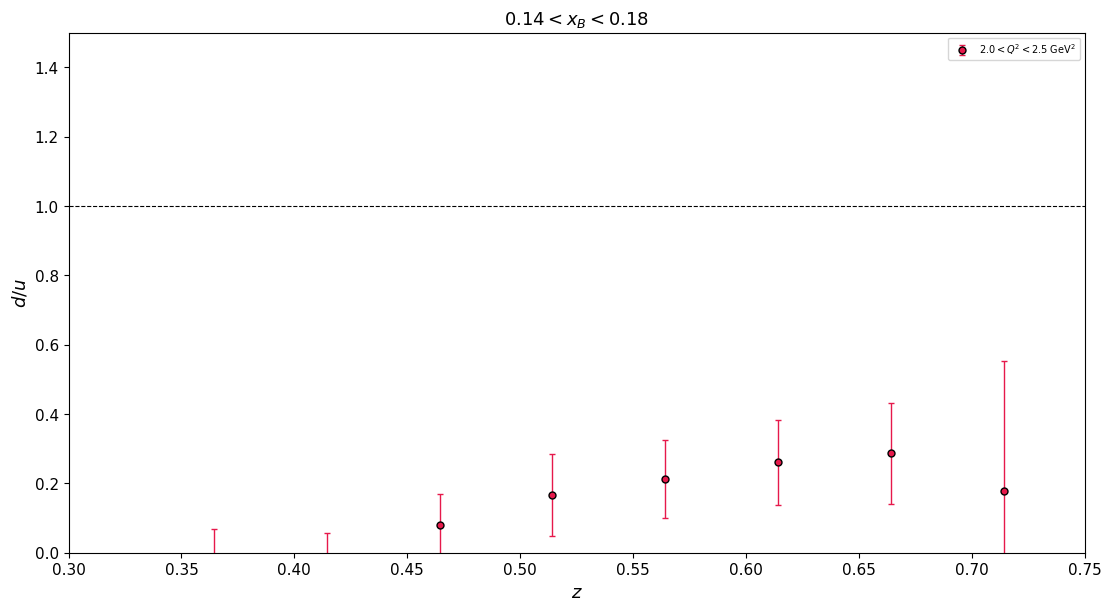

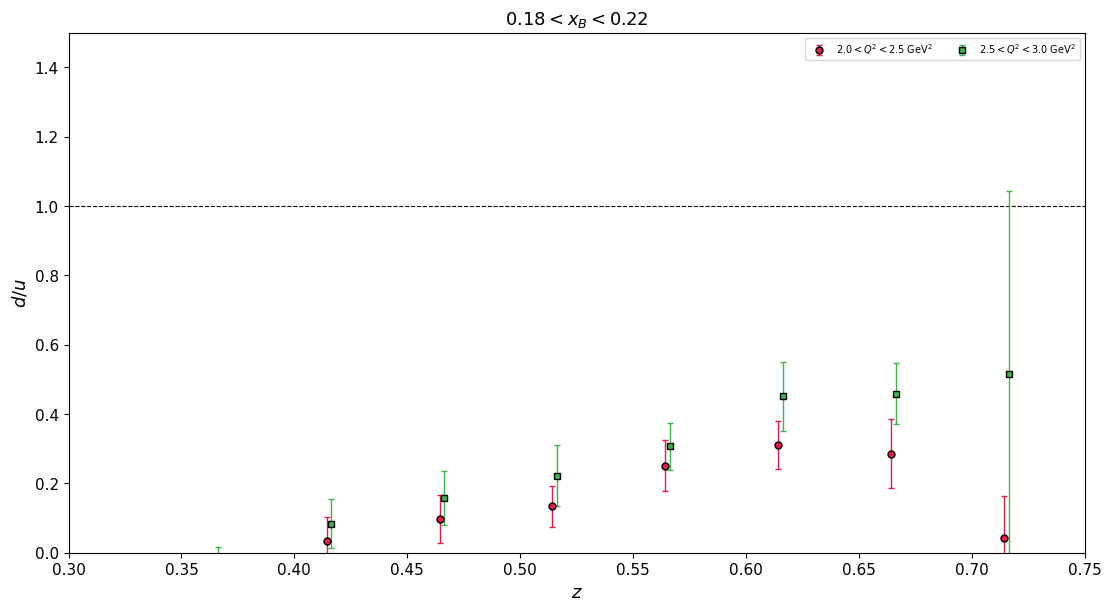

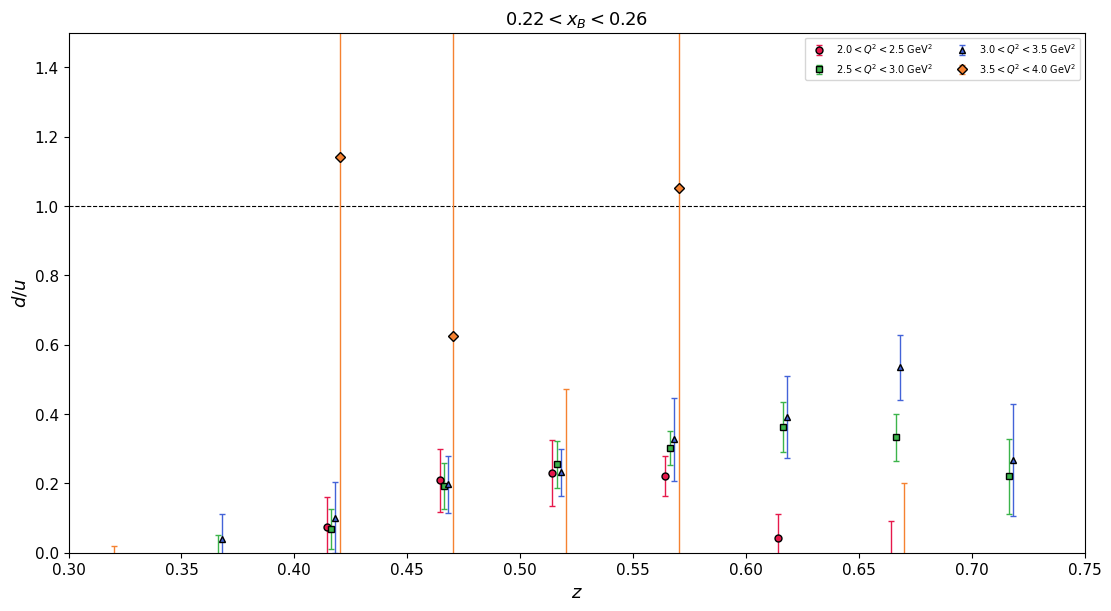

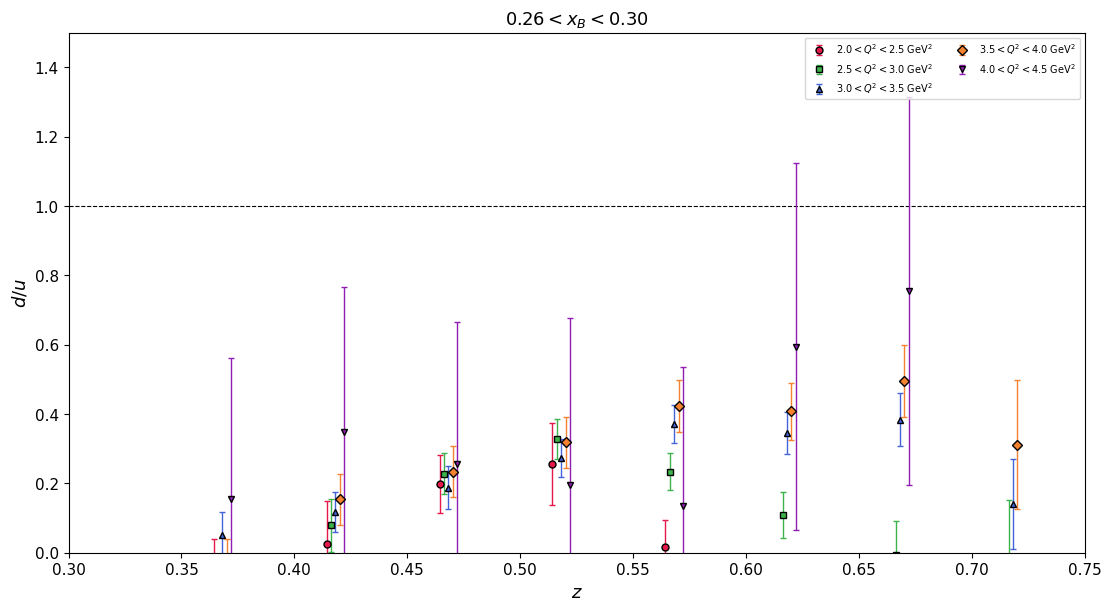

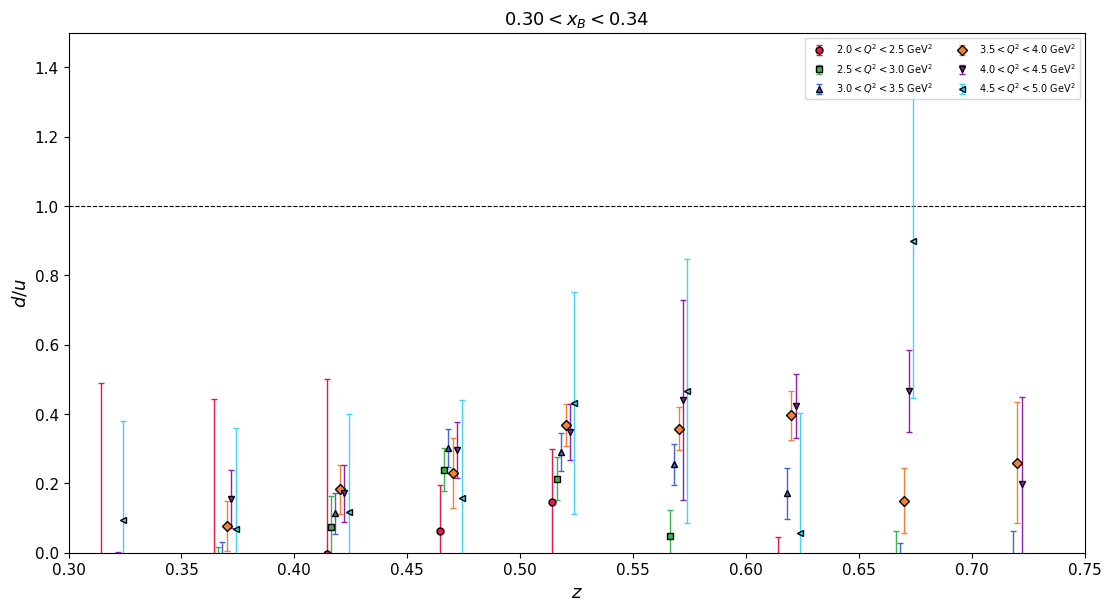

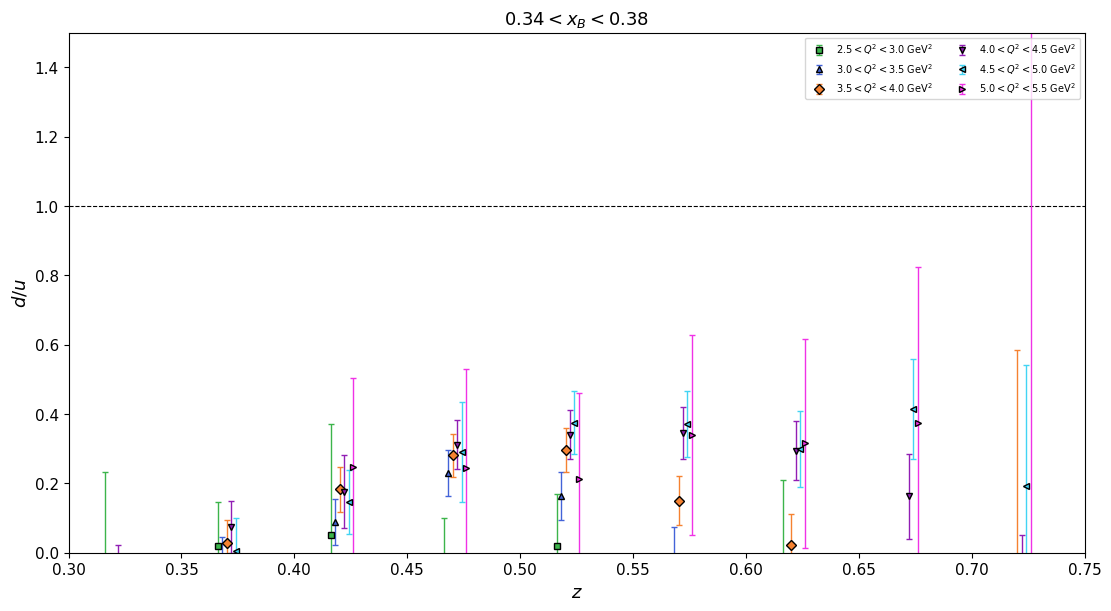

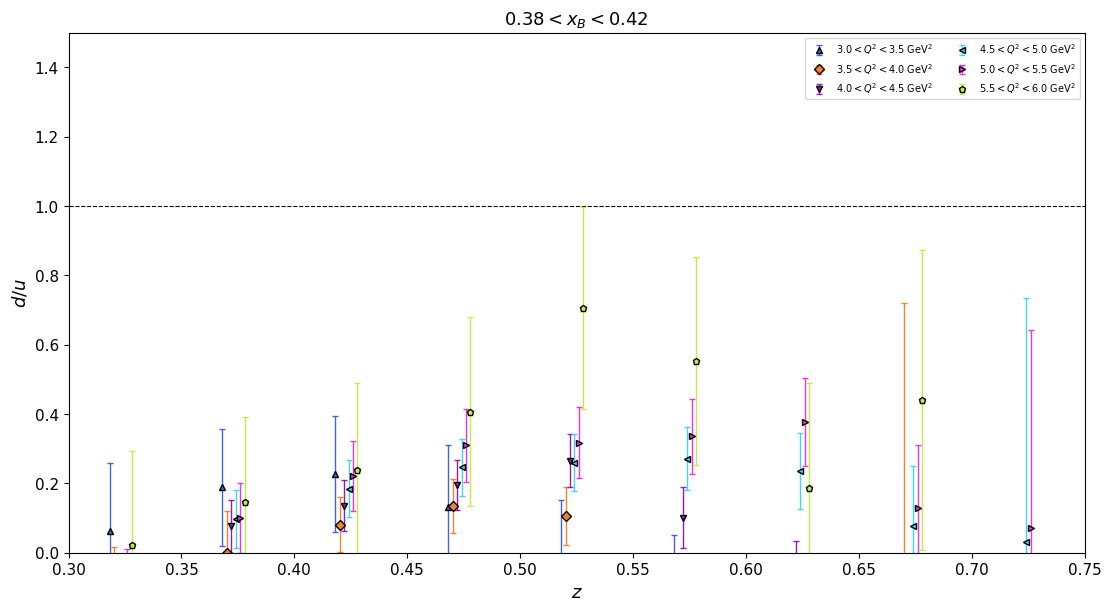

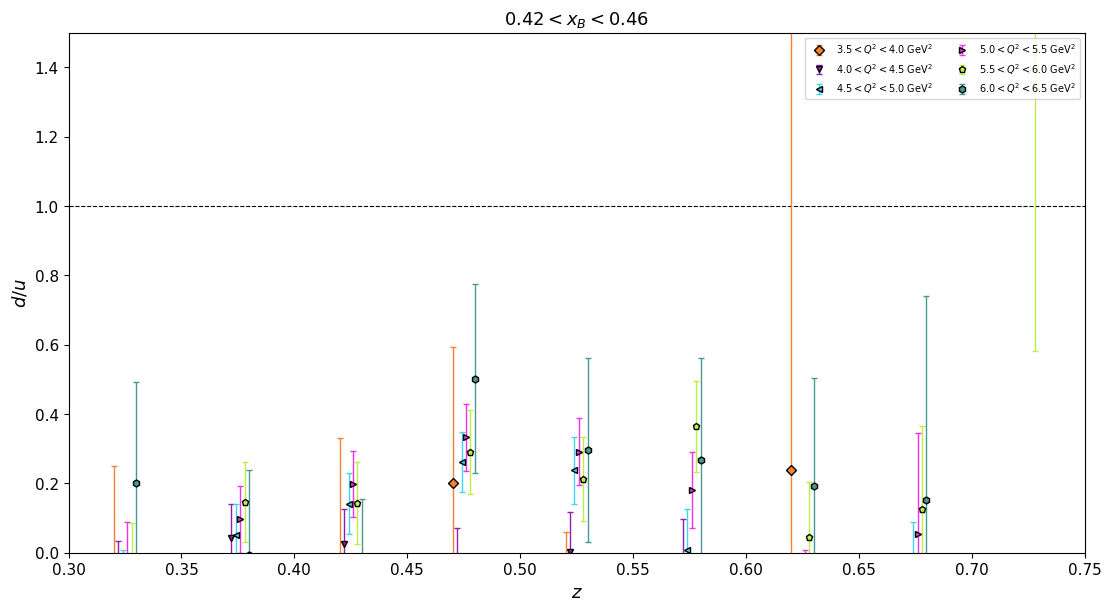

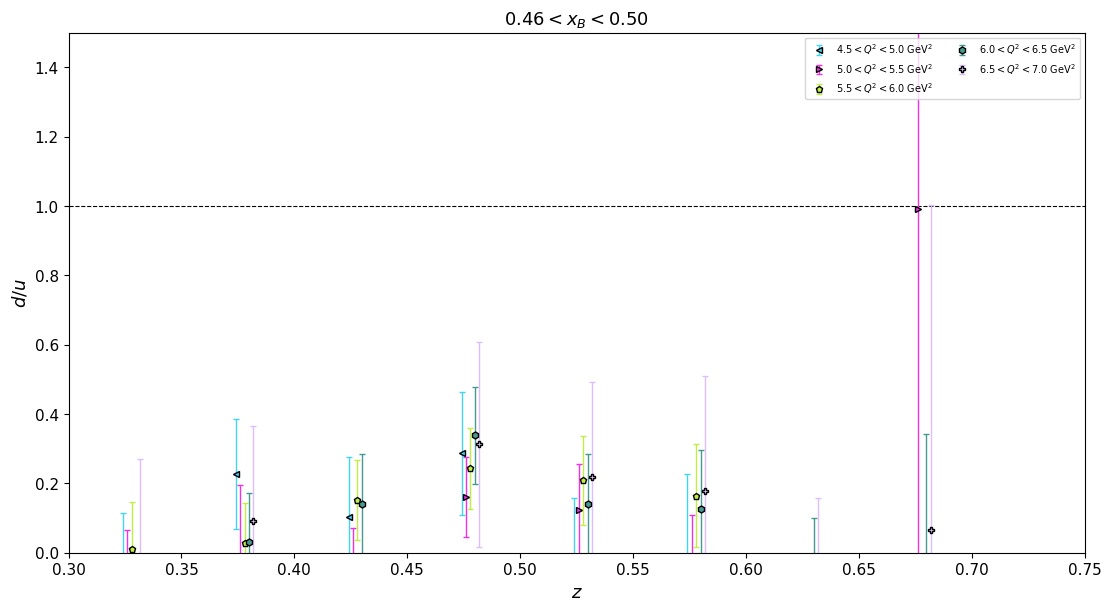

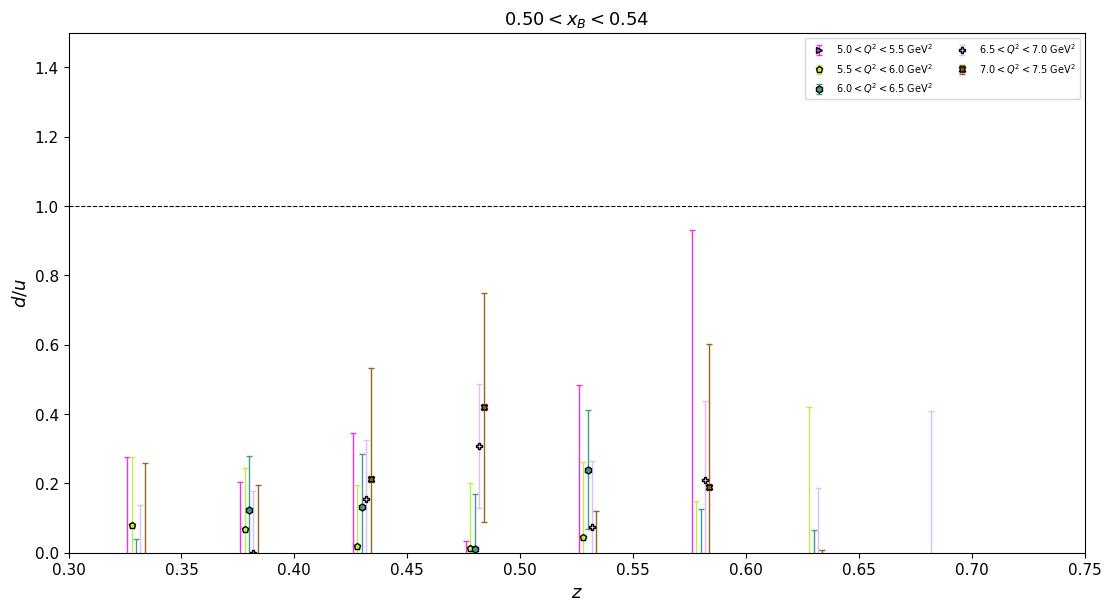

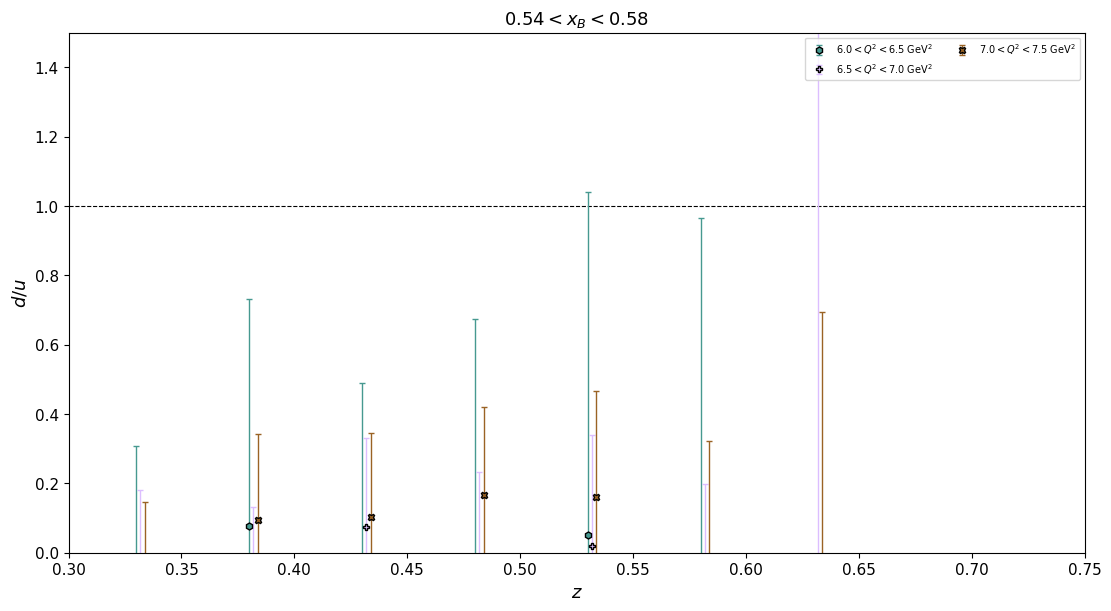

In [ ]:
# ── Plot ──────────────────────────────────────────────────────────────────────
if OUT_DIR:
    os.makedirs(OUT_DIR, exist_ok=True)

colors_list = [
    '#e6194b','#3cb44b','#4363d8','#f58231','#911eb4',
    '#42d4f4','#f032e6','#bfef45','#469990','#dcbeff',
    '#9a6324','#800000','#aaffc3','#a9a9a9'
]
markers = ['o','s','^','D','v','<','>','p','h','P','X','*','d','H']

def _get_dOu(q, x):
    """Load both files and return (dOu, err, z_centers) or None."""
    rd = load_ratio(inFile_d, q, x)
    rp = load_ratio(inFile_p, q, x)
    if rd is None or rp is None:
        return None
    sig_d, err_d, centers = rd
    sig_p, err_p, _       = rp
    # Mask invalid bins
    mask = (sig_d > 0) & (sig_p > 0) & np.isfinite(sig_d) & np.isfinite(sig_p)
    sig_d = np.where(mask, sig_d, np.nan)
    sig_p = np.where(mask, sig_p, np.nan)
    err_d = np.where(mask, err_d, np.nan)
    err_p = np.where(mask, err_p, np.nan)
    val, err = compute_dOu(sig_d, sig_p, err_d, err_p)
    if not np.any(np.isfinite(val)):
        return None
    return val, err, centers

# ── fixed_xq: one figure per xB bin, grid of Q2 subpanels ────────────────────
if MODE == 'fixed_xq':
    NCOLS = 4
    nrows = -(-BINS_Q2 // NCOLS)

    for ix in range(BINS_XB):
        fig, axs = plt.subplots(
            nrows, NCOLS, figsize=(NCOLS * 3.5, nrows * 3.2),
            sharex=True, sharey=True, layout='constrained'
        )
        fig.suptitle(xb_label(ix), fontsize=13)
        axs_flat = axs.ravel()
        has_data = False

        for iq in range(BINS_Q2):
            ax = axs_flat[iq]
            ax.axhline(1, color='black', linestyle='--', lw=0.8)
            ax.text(0.97, 0.97, q2_label(iq), transform=ax.transAxes,
                    ha='right', va='top', fontsize=6.5,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#aaa', alpha=0.8))

            result = _get_dOu(iq, ix)
            if result is not None:
                val, err, centers = result
                mask = np.isfinite(val)
                ax.errorbar(centers[mask], val[mask], err[mask],
                            marker='o', color='#4363d8', linestyle='',
                            capsize=2, lw=1, capthick=1, markersize=4, mec='black')
                has_data = True

            ax.set_ylim(0, 1.02)
            ax.set_xlim(0.3, 0.75)
            ax.tick_params(labelsize=8)
            col = iq % NCOLS
            row = iq // NCOLS
            if col == 0: ax.set_ylabel(r'$d/u$', fontsize=9)
            if row == nrows - 1: ax.set_xlabel(r'$z$', fontsize=9)

        for iq in range(BINS_Q2, nrows * NCOLS):
            axs_flat[iq].set_visible(False)

        if not has_data:
            plt.close(fig)
            continue

        if OUT_DIR:
            fname = f"{OUT_DIR}/dOu_fixed_xq_x{ix+1}.png"
            fig.savefig(fname, dpi=150, bbox_inches='tight')
            plt.close(fig)
            print(f"Saved {fname}")
        else:
            plt.show()

# ── fixed_x / fixed_q ────────────────────────────────────────────────────────
else:
    if MODE == 'fixed_x':
        n_outer, n_inner = BINS_XB, BINS_Q2
        outer_label = xb_label
        inner_label = q2_label
        def get_indices(outer, inner): return inner, outer   # q, x
    else:  # fixed_q
        n_outer, n_inner = BINS_Q2, BINS_XB
        outer_label = q2_label
        inner_label = xb_label
        def get_indices(outer, inner): return outer, inner   # q, x

    z_span  = sample[2][-1] - sample[2][0]
    offsets = np.linspace(-(n_inner-1)/2, (n_inner-1)/2, n_inner) * z_span * 0.003

    for outer in range(n_outer):
        fig, ax = plt.subplots(figsize=(11, 6), layout='constrained')
        edit_ax(ax)
        ax.set_title(outer_label(outer), fontsize=13)
        has_data = False

        for inner in range(n_inner):
            q, x   = get_indices(outer, inner)
            result = _get_dOu(q, x)
            if result is None:
                continue
            val, err, centers = result
            mask   = np.isfinite(val)
            z_plot = centers + offsets[inner]
            color  = colors_list[inner % len(colors_list)]
            marker = markers[inner % len(markers)]
            ax.errorbar(z_plot[mask], val[mask], err[mask],
                        marker=marker, color=color, linestyle='',
                        capsize=2, lw=1, capthick=1, markersize=5, mec='black',
                        label=inner_label(inner))
            has_data = True

        if not has_data:
            plt.close(fig)
            continue

        ax.legend(fontsize=7, loc='upper right', ncol=2)

        if OUT_DIR:
            fname = f"{OUT_DIR}/dOu_{MODE}_{outer+1}.png"
            fig.savefig(fname, dpi=150)
            plt.close(fig)
            print(f"Saved {fname}")
        else:
            plt.show()